<img src='images/Practicum_AI_Logo.white_outline.svg' width=250 alt='Practicum AI logo'> <img src='https://github.com/PracticumAI/practicumai.github.io/blob/main/images/icons/practicumai_python.png?raw=true' align='right' width=50>

***

# Data Visualization with Matplotlib



In this lesson, we're going to be exploring some USDA data on energy use in agriculture [[1](#Citations)]. **Check out [the description of the data](https://data.nal.usda.gov/dataset/data-chapter-5-energy-use-agriculture-us-agriculture-and-forestry-greenhouse-gas-inventory-1990-2018) before continuing.**

It is probably also a good idea to **open a tab with the [`matplotlib` documentation](https://matplotlib.org/stable/api/index.html).**

## Let's get plotting!

Just as with the other packages, `matplotlib` needs to be imported. It is good practice to use an abbreviation as we used `pd` for Pandas. The standard abbreviation for `matplotlib.pyplot` is `plt`.

In [2]:
pip install matplotlib pandas

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 42.2 MB/s  0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------  10.7/11.0 MB 72.3 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 50.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 44.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------  12.6/12.8 MB 72.4 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 55.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 57.4 MB/s  0:00:00

   ----------------------------------------  0/11 [pytz]
   ----------------------------------------  0/11 [pytz]
   ---

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Load and examine the data\n
\n
Now, let's load the data. We'll be loading in \"Data for Figure 5-2: Energy use in agriculture, by source, 1965–2018 in QBTU (quadrillion British thermal units)\". We've included a copy of this CSV file in the data folder.

In [4]:
file_path = 'data/Figure5_2.csv'
energy_data = pd.read_csv(file_path)

In [5]:
# Take a look at the data\n
energy_data.head()

,Year,Gasoline,Diesel,LP gas,Natural Gas,Electricity
0,1965,0.654,0.203,0.110,0.135,0.037
1,1966,0.604,0.230,0.111,0.140,0.039
2,1967,0.570,0.252,0.112,0.143,0.039
3,1968,0.572,0.265,0.113,0.146,0.042
4,1969,0.550,0.293,0.114,0.150,0.045


In [6]:
# Get some summary statistics\n
energy_data.describe()

,Year,Gasoline,Diesel,LP gas,Natural Gas,Electricity
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,1991.500000,0.268656,0.425486,0.084745,0.089057,0.118187
std,15.732133,0.174705,0.088490,0.019747,0.038490,0.043400
min,1965.000000,0.094655,0.203000,0.052852,0.028000,0.037000
25%,1978.250000,0.133326,0.380630,0.070226,0.063056,0.099250
50%,1991.500000,0.184758,0.431500,0.080057,0.074699,0.118708
75%,2004.750000,0.431750,0.478755,0.099500,0.115750,0.145962
max,2018.000000,0.654000,0.612636,0.126000,0.173000,0.193559


## Plotting with `matplotlib`

The `matplotlib` package is the most widely used plotting library for Python. It provides a lot of flexibility for creating a wide variety of plots.

A `matplotlib` plot is composed of several elements. The `Figure` is the overall window or page that everything is drawn on. Into the `Figure` go one or more `Axes`. The `Axes` is the area on which the data are plotted with functions like `plot()` and `scatter()` and that can have ticks, labels, etc. associated with it.

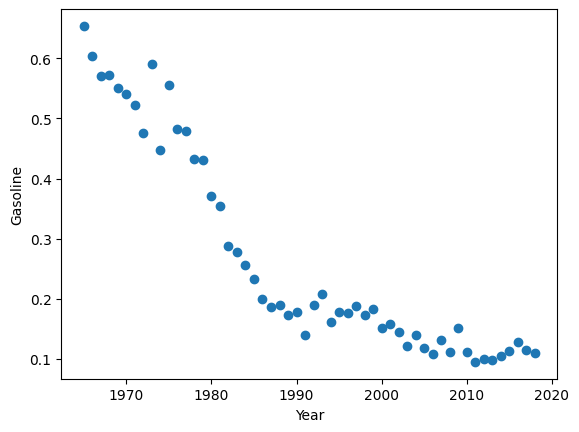

In [7]:
# Create a figure and an axes
fig, ax = plt.subplots()

# Plot Gasoline consumption vs. Year
ax.scatter(energy_data['Year'], energy_data['Gasoline'])

# Set the labels
ax.set_xlabel('Year')
ax.set_ylabel('Gasoline')

# Show the plot
plt.show()

### <img src='images/note_icon.svg' alt="Note icon" width=40 align=center> Note

- The `plt.subplots()` function creates a figure and a set of subplots. By default, it creates one subplot.
- We can use the `ax` object to plot the data and customize the plot.
- We use `plt.show()` at the end to display the plot.

### <img src='images/exercise_icon.svg' alt="Exercise icon" width=40 align=center> Exercise 1

> Make a plot similar to the Gasoline plot above but for one of the other energy sources.

In [ ]:
# Add your code here

# Building your plots iteratively

Building plots with `matplotlib` is also an iterative process. We start by creating a figure and axes, then we add data and customize the appearance.

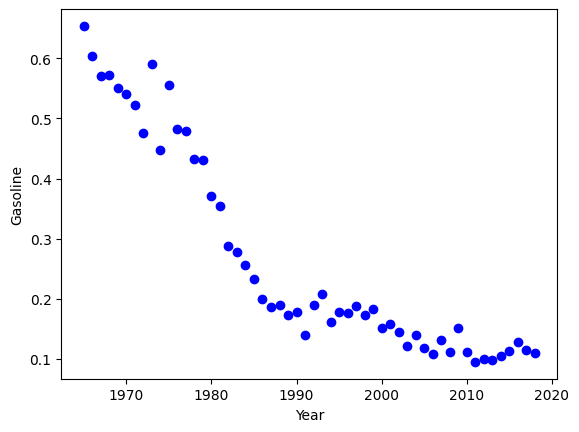

In [8]:
fig, ax = plt.subplots()
ax.scatter(energy_data['Year'], energy_data['Gasoline'], color='blue')
ax.set_xlabel('Year')
ax.set_ylabel('Gasoline')
plt.show()

Maybe we want to try a different `marker`.

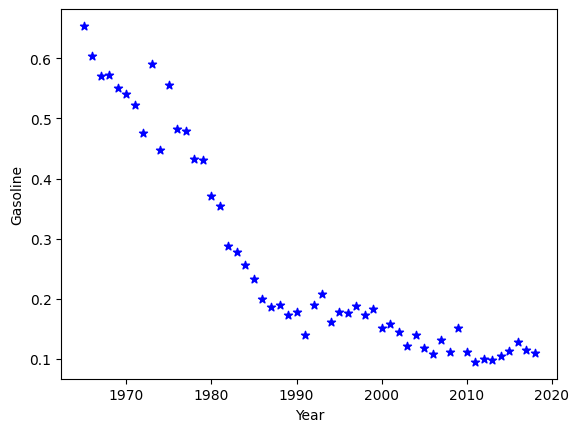

In [9]:
fig, ax = plt.subplots()
ax.scatter(energy_data['Year'], energy_data['Gasoline'], color='blue', marker='*')
ax.set_xlabel('Year')
ax.set_ylabel('Gasoline')
plt.show()

Those stars are a bit small, let's change their `s` (size).

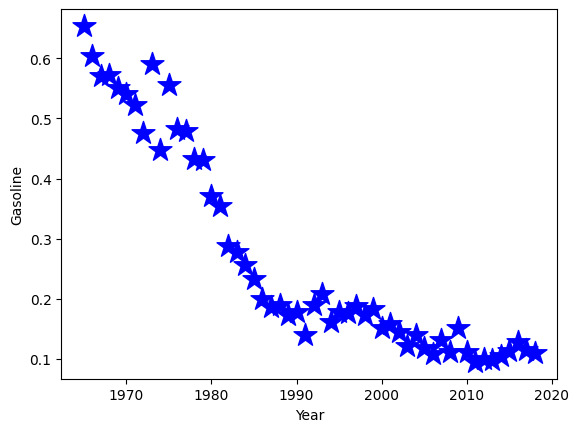

In [11]:
fig, ax = plt.subplots()
ax.scatter(energy_data['Year'], energy_data['Gasoline'], color='blue', marker='*', s=300)
ax.set_xlabel('Year')
ax.set_ylabel('Gasoline')
plt.show()

## Plotting Multiple Columns of Data

With `matplotlib`, we can plot multiple columns of data by calling a plotting function (e.g., `ax.plot()` or `ax.scatter()`) for each column we want to plot. It's often useful to loop through the columns.

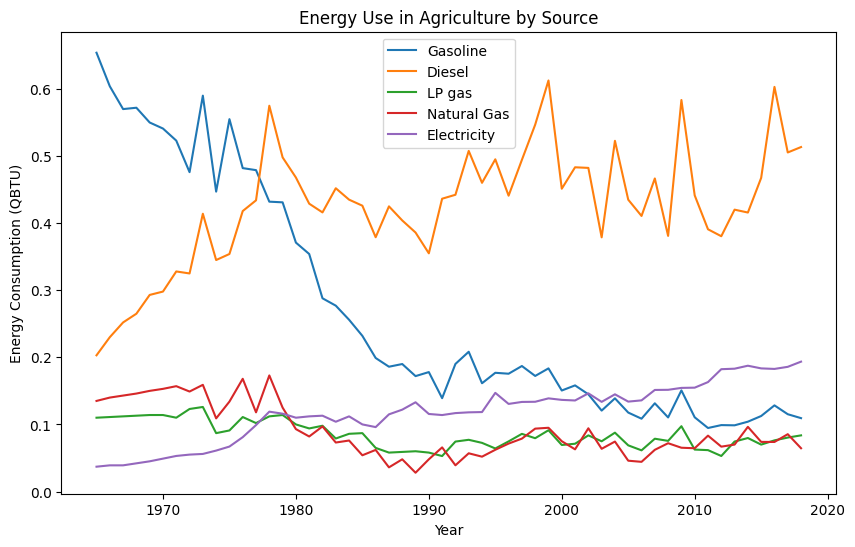

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

energy_sources = energy_data.columns.drop('Year')

for source in energy_sources:
    ax.plot(energy_data['Year'], energy_data[source], label=source)

ax.set_xlabel('Year')
ax.set_ylabel('Energy Consumption (QBTU)')
ax.set_title('Energy Use in Agriculture by Source')
ax.legend()

plt.show()

Looking better!! `matplotlib` even made a nice legend for us!

### <img src='images/exercise_icon.svg' alt="Exercise icon" width=40 align=center> Exercise 2

This is looking good! 

There are a few more things we could do. Use the [`matplotlib` documentation](https://matplotlib.org/stable/api/index.html) to:

* Make the lines a bit thicker.
* Add a grid to the plot.
* Anything else you want to explore!

In [ ]:
# Add your code here

And that's it! We encourage you to keep playing with code, and look out for more Practicum AI lessons!

## Citations

[1]
(original article) Xiarchos, I.M. (2022). Chapter 5: Energy Use in Agriculture. In U.S. Agriculture and Forestry Greenhouse Gas Inventory: 1990–2018. Technical Bulletin No. 1957, United States Department of Agriculture, Office of the Chief Economist, Washington, DC. p. 177-181. January 2022. Hanson, W.L., S.J. Del Grosso, L. Gallagher, Eds.

(dataset) Xiarchos, Irene M. (2021). Data from: Chapter 5: Energy Use in Agriculture. U.S. Agriculture and Forestry Greenhouse Gas Inventory: 1990-2018. Ag Data Commons. https://doi.org/10.15482/USDA.ADC/1524410. Accessed 2023-11-30.